In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.paths import project_dir
from src.data.analysis import read_tiff_img, Circle, create_circular_mask
from src.data.detector import DetectorDataCollection, DetectorData, DetectorImage

In [2]:
colors = [(0, 1, 0), (1, 0, 0)]  # green -> red
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

In [3]:
# local paths
base_path = project_dir / 'data' / 'raw'
#base_path = Path.home() / 'OneDrive - ifj.edu.pl' / 'Projects' / 'MB_foils'

base_path.exists()

True

In [4]:
proton_path = base_path / '2025-10-09'
proton_path.exists()

True

In [5]:
import pickle
with open(proton_path / 'proton_denoised_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [6]:
left_image = data.data[1].raw.image
right_image = data.data[2].raw.image

In [7]:
left_circle = data.data[1].circle
right_circle = data.data[2].circle
left_circle, right_circle 

(Circle(x=229.5, y=192.5, r=133.60000610351562),
 Circle(x=227.5, y=192.5, r=129.89999389648438))

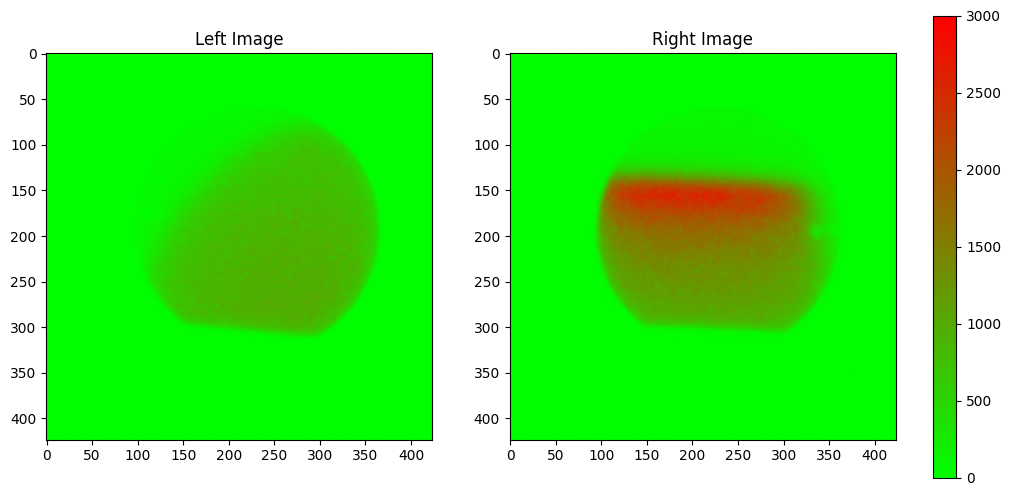

In [8]:
# plot left and right image side by side with vmax 3000 and custom cmap, add colorbar with colorscale
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im1 = ax[0].imshow(left_image, cmap=custom_cmap, vmax=3000)
ax[0].set_title('Left Image')
im2 = ax[1].imshow(right_image, cmap=custom_cmap, vmax=3000)
ax[1].set_title('Right Image')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

In [9]:
# Data classes and computation functions for vertical sections
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class SectionResult:
    x: int
    profile: np.ndarray
    crossing_y: Optional[float]  # fractional y if found, else None

@dataclass
class ImageSections:
    image_name: str
    sections: List[SectionResult]


def compute_vertical_sections(img: np.ndarray, xs: List[int], stripe_width: int = 5, threshold: float = 400.0, search_from_bottom: bool = True) -> ImageSections:
    """Compute vertical profiles and interpolated crossings for given x positions.

    Returns an ImageSections object with per-section profiles and crossing points (fractional y).
    """
    import numpy as np
    h, w = img.shape
    half = stripe_width // 2

    def find_crossing_interpolated_bottom_to_top(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        last_idx = int(idxs.max())
        if last_idx == 0:
            return float(y0)
        prev = last_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[last_idx])
        if v_high == v_low:
            return float(y0 + last_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    def find_crossing_interpolated_top_to_bottom(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        first_idx = int(idxs[0])
        if first_idx == 0:
            return float(y0)
        prev = first_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[first_idx])
        if v_high == v_low:
            return float(y0 + first_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    finder = find_crossing_interpolated_bottom_to_top if search_from_bottom else find_crossing_interpolated_top_to_bottom

    sections: List[SectionResult] = []
    for x in xs:
        x0 = max(0, int(x - half))
        x1 = min(w, int(x + half + 1))
        section = img[:, x0:x1].astype(float)
        profile = np.nanmean(section, axis=1)
        y0_win, y1_win = 0, h
        crossing = finder(profile, threshold, y0_win, y1_win)
        sections.append(SectionResult(x=int(x), profile=profile, crossing_y=crossing))

    return ImageSections(image_name='image', sections=sections)


# Quick compute results for both images to make results available
left_sections = compute_vertical_sections(left_image, xs=[160,180,200,220,240,260,280], stripe_width=10, threshold=400, search_from_bottom=True)
right_sections = compute_vertical_sections(right_image, xs=[160,180,200,220,240,260,280], stripe_width=10, threshold=400, search_from_bottom=True)

print('Computed sections for left and right images')


Computed sections for left and right images


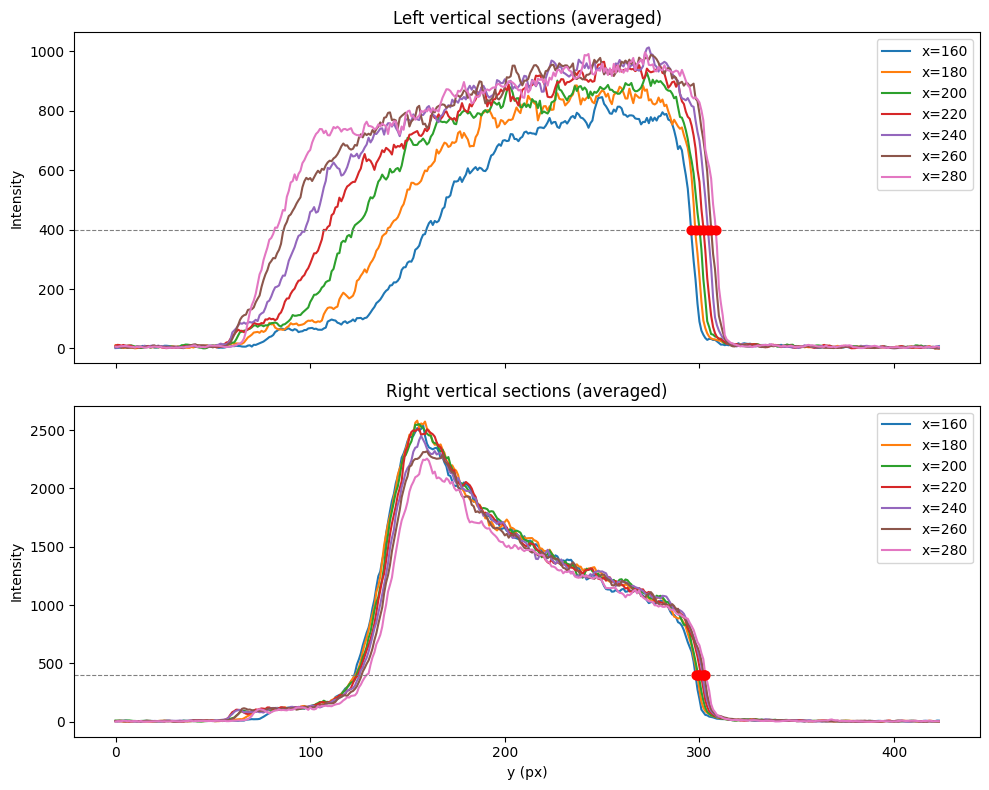

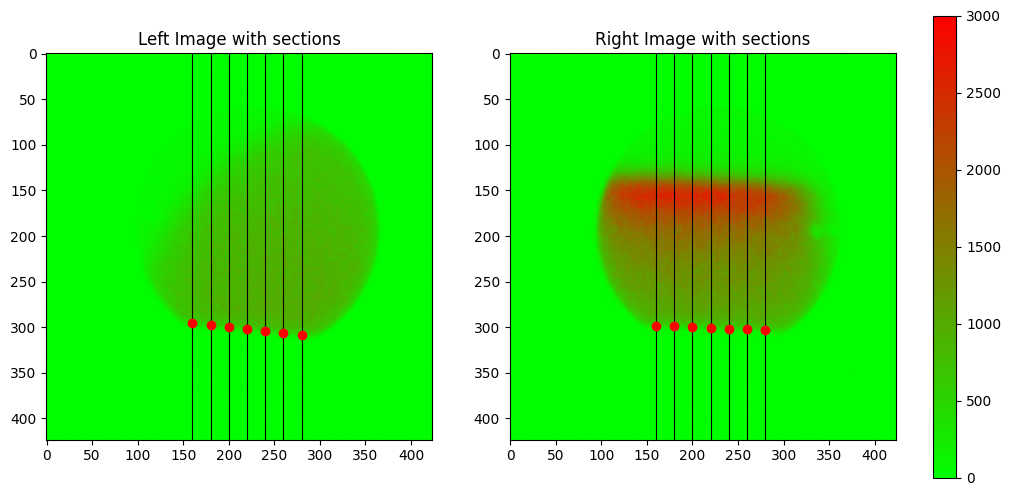

In [10]:
# Plotting functions that take ImageSections and draw plots

def plot_sections_profiles(left_sections: ImageSections, right_sections: ImageSections, threshold: float = 400.0):
    import matplotlib.pyplot as plt
    import numpy as np

    # assume both have same xs
    xs = [s.x for s in left_sections.sections]
    h = left_sections.sections[0].profile.size

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, x in enumerate(xs):
        prof_l = left_sections.sections[i].profile
        prof_r = right_sections.sections[i].profile
        axs[0].plot(np.arange(h), prof_l, label=f'x={x}')
        axs[1].plot(np.arange(h), prof_r, label=f'x={x}')
        cl = left_sections.sections[i].crossing_y
        cr = right_sections.sections[i].crossing_y
        if cl is not None:
            axs[0].scatter(cl, threshold, s=40, color='red', zorder=5)
        if cr is not None:
            axs[1].scatter(cr, threshold, s=40, color='red', zorder=5)

    axs[0].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axs[1].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axs[0].set_title('Left vertical sections (averaged)')
    axs[0].set_ylabel('Intensity')
    axs[0].legend()
    axs[1].set_title('Right vertical sections (averaged)')
    axs[1].set_ylabel('Intensity')
    axs[1].set_xlabel('y (px)')
    axs[1].legend()
    plt.tight_layout()
    plt.show()


def overlay_sections_on_images(left_img, right_img, left_sections: ImageSections, right_sections: ImageSections):
    import matplotlib.pyplot as plt

    h, w = left_img.shape
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(left_img, cmap=custom_cmap, vmax=3000)
    ax[0].set_title('Left Image with sections')
    im1 = ax[1].imshow(right_img, cmap=custom_cmap, vmax=3000)
    ax[1].set_title('Right Image with sections')

    xs = [s.x for s in left_sections.sections]
    for s in left_sections.sections:
        ax[0].plot([s.x, s.x], [0, h-1], color='black', linewidth=0.8)
        if s.crossing_y is not None:
            ax[0].plot(s.x, s.crossing_y, 'ro', markersize=6)
    for s in right_sections.sections:
        ax[1].plot([s.x, s.x], [0, h-1], color='black', linewidth=0.8)
        if s.crossing_y is not None:
            ax[1].plot(s.x, s.crossing_y, 'ro', markersize=6)

    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# Example usage with computed left_sections and right_sections
plot_sections_profiles(left_sections, right_sections, threshold=400)
overlay_sections_on_images(left_image, right_image, left_sections, right_sections)


In [11]:
# Dataclass for line result and function to compute a near-horizontal line from SectionResults
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class LineResult:
    slope: float
    intercept: float
    slope_deg: float
    used_points: List[Tuple[float, float]]  # list of (x, y)


def compute_edge_line(image_sections: ImageSections, min_points: int = 2, robust: bool = True) -> Optional[LineResult]:
    """Fit a line y = m*x + b through the crossing points from image_sections.

    Uses simple least squares; if robust option is True and scikit-learn is available, uses RANSAC.
    Returns None if not enough points.
    """
    import numpy as np
    xs = []
    ys = []
    for s in image_sections.sections:
        if s.crossing_y is not None:
            xs.append(float(s.x))
            ys.append(float(s.crossing_y))
    if len(xs) < min_points:
        return None
    xs_arr = np.array(xs)
    ys_arr = np.array(ys)

    # try robust fit with sklearn if available
    if robust:
        try:
            from sklearn.linear_model import RANSACRegressor, LinearRegression
            model = RANSACRegressor(LinearRegression(), min_samples=max(2, int(0.5 * len(xs_arr))))
            model.fit(xs_arr.reshape(-1, 1), ys_arr)
            m = float(model.estimator_.coef_[0])
            b = float(model.estimator_.intercept_)
            # compute inlier mask
            inlier_mask = model.inlier_mask_
            xs_used = xs_arr[inlier_mask].tolist()
            ys_used = ys_arr[inlier_mask].tolist()
        except Exception:
            # fallback to simple polyfit
            p = np.polyfit(xs_arr, ys_arr, 1)
            m, b = float(p[0]), float(p[1])
            xs_used = xs_arr.tolist()
            ys_used = ys_arr.tolist()
    else:
        p = np.polyfit(xs_arr, ys_arr, 1)
        m, b = float(p[0]), float(p[1])
        xs_used = xs_arr.tolist()
        ys_used = ys_arr.tolist()

    slope_deg = float(np.degrees(np.arctan(m)))
    used_pts = list(zip(xs_used, ys_used))
    return LineResult(slope=m, intercept=b, slope_deg=slope_deg, used_points=used_pts)


Left fitted slope (deg): 5.9646864317477295
Right fitted slope (deg): 2.3774095682113843


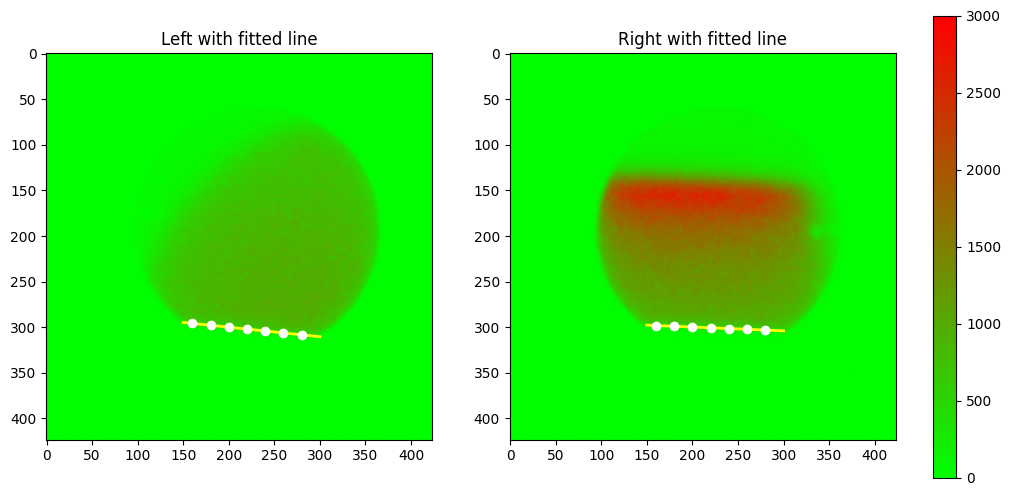

In [12]:
# Compute and overlay fitted lines on images
left_line = compute_edge_line(left_sections, robust=True)
right_line = compute_edge_line(right_sections, robust=True)

print('Left fitted slope (deg):', left_line.slope_deg if left_line else None)
print('Right fitted slope (deg):', right_line.slope_deg if right_line else None)

# function to overlay LineResult on existing overlay plot

def overlay_line_on_images(left_img, right_img, left_line: LineResult, right_line: LineResult, x_range=None, color='lime'):
    import numpy as np
    import matplotlib.pyplot as plt
    h, w = left_img.shape
    if x_range is None:
        x_range = (0, w-1)
    xs_plot = np.array([x_range[0], x_range[1]])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(left_img, cmap=custom_cmap, vmax=3000)
    ax[0].set_title('Left with fitted line')
    im1 = ax[1].imshow(right_img, cmap=custom_cmap, vmax=3000)
    ax[1].set_title('Right with fitted line')

    if left_line is not None:
        y0 = left_line.slope * xs_plot[0] + left_line.intercept
        y1 = left_line.slope * xs_plot[1] + left_line.intercept
        ax[0].plot(xs_plot, [y0, y1], color=color, linewidth=2)
        # mark used points
        for (x, y) in left_line.used_points:
            ax[0].plot(x, y, 'wo')
    if right_line is not None:
        y0 = right_line.slope * xs_plot[0] + right_line.intercept
        y1 = right_line.slope * xs_plot[1] + right_line.intercept
        ax[1].plot(xs_plot, [y0, y1], color=color, linewidth=2)
        for (x, y) in right_line.used_points:
            ax[1].plot(x, y, 'wo')

    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# Show overlay with lines
overlay_line_on_images(left_image, right_image, left_line, right_line, x_range=(150, 300), color='yellow')


In [21]:
# Function to rotate images by the calculated slope angle
def rotate_image_by_slope(img: np.ndarray, line_result: LineResult, order: int = 3, cval: float = 0.0) -> np.ndarray:
    """Rotate image to make the fitted edge horizontal.
    
    Args:
        img: Input image array
        line_result: LineResult object containing slope information
        order: Interpolation order (0=nearest, 1=linear, 3=cubic)
        cval: Value to use for pixels outside image boundaries
    
    Returns:
        Rotated image array
    """
    if line_result is None:
        return img
    
    # Rotate by negative of the slope angle to make edge horizontal
    angle_deg = line_result.slope_deg
    
    # Use scipy.ndimage.rotate for rotation
    rotated = ndi.rotate(img, angle_deg, reshape=False, order=order, cval=cval)
    
    return rotated


In [22]:
# Rotate both images using the calculated slope angles
left_image_rotated = rotate_image_by_slope(left_image, left_line, order=3, cval=0.0)
right_image_rotated = rotate_image_by_slope(right_image, right_line, order=3, cval=0.0)

print(f'Left image rotated by {-left_line.slope_deg:.3f} degrees')
print(f'Right image rotated by {-right_line.slope_deg:.3f} degrees')
print(f'Rotated image shapes: {left_image_rotated.shape}, {right_image_rotated.shape}')


Left image rotated by -5.965 degrees
Right image rotated by -2.377 degrees
Rotated image shapes: (424, 424), (424, 424)


In [23]:
# Function to plot rotated images
def plot_rotated_images(left_img_rot, right_img_rot, left_img_orig=None, right_img_orig=None, vmax=3000):
    """Plot rotated images, optionally comparing with original images.
    
    Args:
        left_img_rot: Rotated left image
        right_img_rot: Rotated right image
        left_img_orig: Original left image (optional, for comparison)
        right_img_orig: Original right image (optional, for comparison)
        vmax: Maximum value for color scale
    """
    import matplotlib.pyplot as plt
    
    if left_img_orig is not None and right_img_orig is not None:
        # Show before and after comparison
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        
        im00 = axes[0, 0].imshow(left_img_orig, cmap=custom_cmap, vmax=vmax)
        axes[0, 0].set_title('Left Image (Original)')
        
        im01 = axes[0, 1].imshow(right_img_orig, cmap=custom_cmap, vmax=vmax)
        axes[0, 1].set_title('Right Image (Original)')
        
        im10 = axes[1, 0].imshow(left_img_rot, cmap=custom_cmap, vmax=vmax)
        axes[1, 0].set_title('Left Image (Rotated)')
        
        im11 = axes[1, 1].imshow(right_img_rot, cmap=custom_cmap, vmax=vmax)
        axes[1, 1].set_title('Right Image (Rotated)')
        
        plt.colorbar(im11, ax=axes, fraction=0.046, pad=0.04)
    else:
        # Show only rotated images
        fig, ax = plt.subplots(1, 2, figsize=(12, 6))
        
        im0 = ax[0].imshow(left_img_rot, cmap=custom_cmap, vmax=vmax)
        ax[0].set_title('Left Image (Rotated)')
        
        im1 = ax[1].imshow(right_img_rot, cmap=custom_cmap, vmax=vmax)
        ax[1].set_title('Right Image (Rotated)')
        
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_26559/2358292696.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


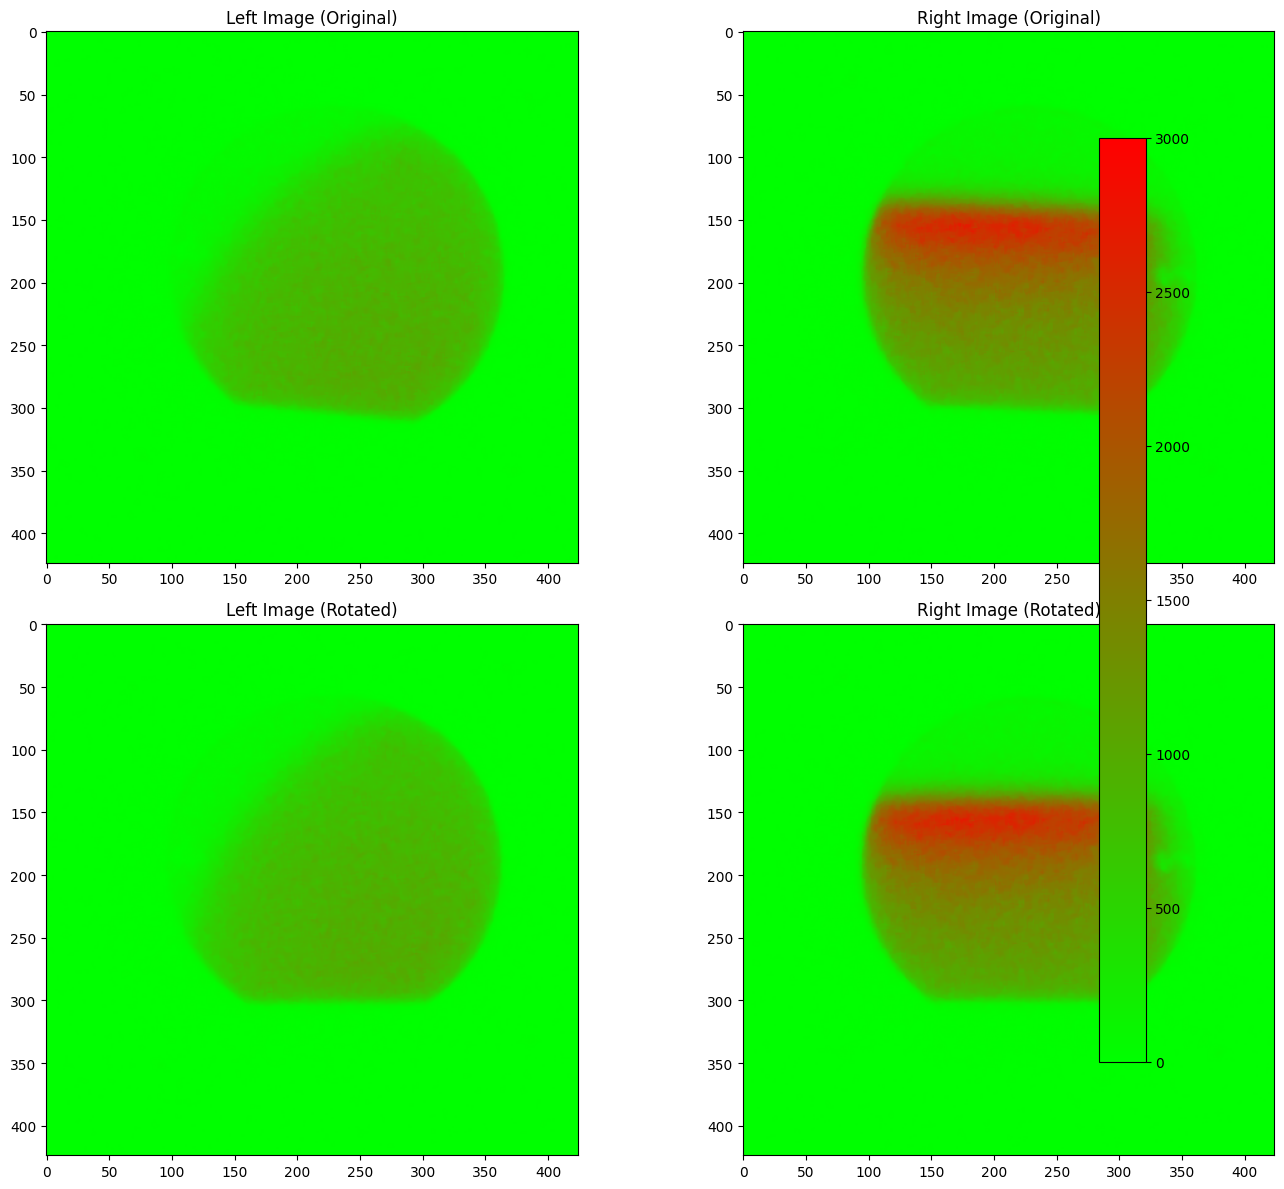

In [24]:
# Plot rotated images with comparison to originals
plot_rotated_images(left_image_rotated, right_image_rotated, 
                   left_img_orig=left_image, right_img_orig=right_image, 
                   vmax=3000)
